In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
df=pd.read_csv('anime.csv')
df.head()

,mal_id,url,approved,title,title_english,title_japanese,title_synonyms,image_jpg_url,image_jpg_small_url,image_jpg_large_url,...,broadcast_time,broadcast_timezone,broadcast_string,producers,licensors,studios,genres,explicit_genres,themes,demographics
0,1,https://myanimelist.net/anime/1/Cowboy_Bebop,True,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,NaN,https://cdn.myanimelist.net/images/anime/4/196...,https://cdn.myanimelist.net/images/anime/4/196...,https://cdn.myanimelist.net/images/anime/4/196...,...,01:00,Asia/Tokyo,Saturdays at 01:00 (JST),"Bandai Visual, Victor Entertainment, Audio Pla...",Funimation,Sunrise,"Action, Award Winning, Sci-Fi",NaN,"Adult Cast, Space",NaN
1,5,https://myanimelist.net/anime/5/Cowboy_Bebop__...,True,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Cowboy Bebop: Knockin' on Heaven's Door,https://cdn.myanimelist.net/images/anime/1439/...,https://cdn.myanimelist.net/images/anime/1439/...,https://cdn.myanimelist.net/images/anime/1439/...,...,NaN,NaN,NaN,"Sunrise, Bandai Visual","Sony Pictures Entertainment, Funimation",Bones,"Action, Sci-Fi",NaN,"Adult Cast, Space",NaN
2,6,https://myanimelist.net/anime/6/Trigun,True,Trigun,Trigun,トライガン,NaN,https://cdn.myanimelist.net/images/anime/1130/...,https://cdn.myanimelist.net/images/anime/1130/...,https://cdn.myanimelist.net/images/anime/1130/...,...,01:15,Asia/Tokyo,Thursdays at 01:15 (JST),Victor Entertainment,Funimation,Madhouse,"Action, Adventure, Sci-Fi",NaN,Adult Cast,Shounen
3,7,https://myanimelist.net/anime/7/Witch_Hunter_R...,True,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),WHR,https://cdn.myanimelist.net/images/anime/10/19...,https://cdn.myanimelist.net/images/anime/10/19...,https://cdn.myanimelist.net/images/anime/10/19...,...,01:25,Asia/Tokyo,Wednesdays at 01:25 (JST),"Bandai Visual, Dentsu, Victor Entertainment","Funimation, Bandai Entertainment",Sunrise,"Action, Drama, Mystery, Supernatural",NaN,Detective,NaN
4,8,https://myanimelist.net/anime/8/Bouken_Ou_Beet,True,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,Adventure King Beet,https://cdn.myanimelist.net/images/anime/7/215...,https://cdn.myanimelist.net/images/anime/7/215...,https://cdn.myanimelist.net/images/anime/7/215...,...,18:30,Asia/Tokyo,Thursdays at 18:30 (JST),"TV Tokyo, Dentsu",Illumitoon Entertainment,Toei Animation,"Action, Adventure, Fantasy",NaN,NaN,Shounen


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28858 entries, 0 to 28857
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mal_id                     28858 non-null  int64  
 1   url                        28858 non-null  object 
 2   approved                   28858 non-null  bool   
 3   title                      28858 non-null  object 
 4   title_english              12435 non-null  object 
 5   title_japanese             28737 non-null  object 
 6   title_synonyms             14266 non-null  object 
 7   image_jpg_url              28858 non-null  object 
 8   image_jpg_small_url        28858 non-null  object 
 9   image_jpg_large_url        28858 non-null  object 
 10  image_webp_url             28858 non-null  object 
 11  image_webp_small_url       28858 non-null  object 
 12  image_webp_large_url       28858 non-null  object 
 13  trailer_youtube_id         5553 non-null   obj

In [37]:
print(df.columns.tolist())

['mal_id', 'url', 'approved', 'title', 'title_english', 'title_japanese', 'title_synonyms', 'image_jpg_url', 'image_jpg_small_url', 'image_jpg_large_url', 'image_webp_url', 'image_webp_small_url', 'image_webp_large_url', 'trailer_youtube_id', 'trailer_url', 'trailer_embed_url', 'trailer_image_url', 'trailer_small_image_url', 'trailer_medium_image_url', 'trailer_large_image_url', 'trailer_maximum_image_url', 'type', 'source', 'episodes', 'status', 'airing', 'duration', 'rating', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites', 'synopsis', 'background', 'aired_from', 'aired_to', 'aired_prop_from_day', 'aired_prop_from_month', 'aired_prop_from_year', 'aired_prop_to_day', 'aired_prop_to_month', 'aired_prop_to_year', 'aired_string', 'season', 'year', 'broadcast_day', 'broadcast_time', 'broadcast_timezone', 'broadcast_string', 'producers', 'licensors', 'studios', 'genres', 'explicit_genres', 'themes', 'demographics']


In [38]:
df['source']

0           Original
1           Original
2              Manga
3           Original
4              Manga
            ...     
28853       Original
28854          Other
28855    Light novel
28856    Light novel
28857       Original
Name: source, Length: 28858, dtype: object

In [39]:
columns_to_keep = [ 'title', 'type', 'source', 'episodes', 'score', 'season', 'year', 'studios', 'genres', 'members', 'scored_by', 'favorites']

df_clean=df[columns_to_keep]
df_clean=df_clean[df_clean['type']=='TV']
df_clean = df_clean.dropna(subset=['score', 'studios', 'genres', 'members', 'scored_by'])

print(f"Original dataset rows: {len(df)}")
print(f"Cleaned TV-only dataset rows: {len(df_clean)}")

display(df_clean.head())

Original dataset rows: 28858
Cleaned TV-only dataset rows: 4803


,title,type,source,episodes,score,season,year,studios,genres,members,scored_by,favorites
0,Cowboy Bebop,TV,Original,26.0,8.75,spring,1998.0,Sunrise,"Action, Award Winning, Sci-Fi",1983687,1023989.0,86885
2,Trigun,TV,Manga,26.0,8.22,spring,1998.0,Madhouse,"Action, Adventure, Sci-Fi",806006,390164.0,16931
3,Witch Hunter Robin,TV,Original,26.0,7.23,summer,2002.0,Sunrise,"Action, Drama, Mystery, Supernatural",123980,45450.0,675
4,Bouken Ou Beet,TV,Manga,52.0,6.92,fall,2004.0,Toei Animation,"Action, Adventure, Fantasy",16333,6970.0,16
5,Eyeshield 21,TV,Manga,145.0,7.91,spring,2005.0,Gallop,Sports,192168,92024.0,2080


In [40]:
df_clean = df_clean.copy()

df_clean['retention_rate'] = df_clean['scored_by'] / df_clean['members']

df_model=df_clean[df_clean['members']>10000].copy()

df_model.set_index('title',inplace=True)

df_model.head()

,type,source,episodes,score,season,year,studios,genres,members,scored_by,favorites,retention_rate
title,,,,,,,,,,,,
Cowboy Bebop,TV,Original,26.0,8.75,spring,1998.0,Sunrise,"Action, Award Winning, Sci-Fi",1983687,1023989.0,86885,0.516205
Trigun,TV,Manga,26.0,8.22,spring,1998.0,Madhouse,"Action, Adventure, Sci-Fi",806006,390164.0,16931,0.484071
Witch Hunter Robin,TV,Original,26.0,7.23,summer,2002.0,Sunrise,"Action, Drama, Mystery, Supernatural",123980,45450.0,675,0.366591
Bouken Ou Beet,TV,Manga,52.0,6.92,fall,2004.0,Toei Animation,"Action, Adventure, Fantasy",16333,6970.0,16,0.426743
Eyeshield 21,TV,Manga,145.0,7.91,spring,2005.0,Gallop,Sports,192168,92024.0,2080,0.478873


In [41]:
# separating comma separated genres into binary (one hot encoding #1)
genres_encoded = df_model['genres'].str.get_dummies(sep=', ')

# grouping tiny studios into "others"
df_model['studios']=df_model['studios'].where(df_model['studios'].isin(df_model['studios'].value_counts().index[:40]),'Other')

# one hot encoding 'source', 'season' and 'studios'
features_encoded=pd.get_dummies(df_model[['source','season','studios']],dtype=int)

final_df=pd.concat([df_model[['retention_rate','episodes','score']],genres_encoded,features_encoded],axis=1)

final_df=final_df.dropna()

display(final_df.head())

,retention_rate,episodes,score,Action,Adventure,Avant Garde,Award Winning,Boys Love,Comedy,Drama,...,studios_Studio Hibari,studios_Sunrise,studios_TMS Entertainment,studios_Tatsunoko Production,studios_Toei Animation,studios_White Fox,studios_Wit Studio,studios_Xebec,studios_Zexcs,studios_feel.
title,,,,,,,,,,,,,,,,,,,,,
Cowboy Bebop,0.516205,26.0,8.75,1,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
Trigun,0.484071,26.0,8.22,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Witch Hunter Robin,0.366591,26.0,7.23,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
Bouken Ou Beet,0.426743,52.0,6.92,1,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
Eyeshield 21,0.478873,145.0,7.91,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
print(final_df.columns.tolist())

['retention_rate', 'episodes', 'score', 'Action', 'Adventure', 'Avant Garde', 'Award Winning', 'Boys Love', 'Comedy', 'Drama', 'Ecchi', 'Erotica', 'Fantasy', 'Girls Love', 'Gourmet', 'Horror', 'Mystery', 'Romance', 'Sci-Fi', 'Slice of Life', 'Sports', 'Supernatural', 'Suspense', 'source_4-koma manga', 'source_Book', 'source_Card game', 'source_Game', 'source_Light novel', 'source_Manga', 'source_Mixed media', 'source_Music', 'source_Novel', 'source_Original', 'source_Other', 'source_Picture book', 'source_Unknown', 'source_Visual novel', 'source_Web manga', 'season_fall', 'season_spring', 'season_summer', 'season_winter', 'studios_8bit', 'studios_A-1 Pictures', 'studios_AIC', 'studios_Arms', 'studios_Bones', "studios_Brain's Base", 'studios_CloverWorks', 'studios_David Production', 'studios_Diomedéa', 'studios_Doga Kobo', 'studios_EMT Squared', 'studios_Gonzo', 'studios_J.C.Staff', 'studios_Kyoto Animation', 'studios_LIDENFILMS', 'studios_Lerche', 'studios_MAPPA', 'studios_Madhouse', '

In [43]:
#training starts! ;)

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [44]:
#i am calculating the industry median and based on that, creating a binary target 
median_retention=final_df['retention_rate'].median()
y=(final_df['retention_rate']>median_retention).astype(int)

#target acquired! now it's time for features
X=final_df.drop(columns='retention_rate')

#for a good model, this is necessary :)
X_temp,X_test,y_temp,y_test=train_test_split(X,y,train_size=0.8,random_state=16) #to get the test set and put it aside for a while
X_train,X_cv,y_train,y_cv=train_test_split(X_temp,y_temp,train_size=0.75,random_state=16) #to get the cross validation set

#settin' up our model and fitting it
model=XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=16)
model.fit(X_train,y_train)

#to check overfitting

y_cv_pred=model.predict(X_cv)
cv_accuracy=accuracy_score(y_cv,y_cv_pred)

y_test_pred=model.predict(X_test)
test_accuracy=accuracy_score(y_test,y_test_pred)

print(f"Industry Median Retention Threshold: {median_retention:.2f}")
print(f"Model's Cross Validation Accuracy : {cv_accuracy*100:.2f}%")
print(f"Model's Accuracy on unseen test data: {test_accuracy*100:.2f}%")

Industry Median Retention Threshold: 0.42
Model's Cross Validation Accuracy : 63.44%
Model's Accuracy on unseen test data: 68.50%


In [45]:
#turns out, no overfitting! ;)

The confidence of model a.k.a hit probabilty is 57.97
Episode 1 viewers: 10000
Episode 12 viewers: 1564


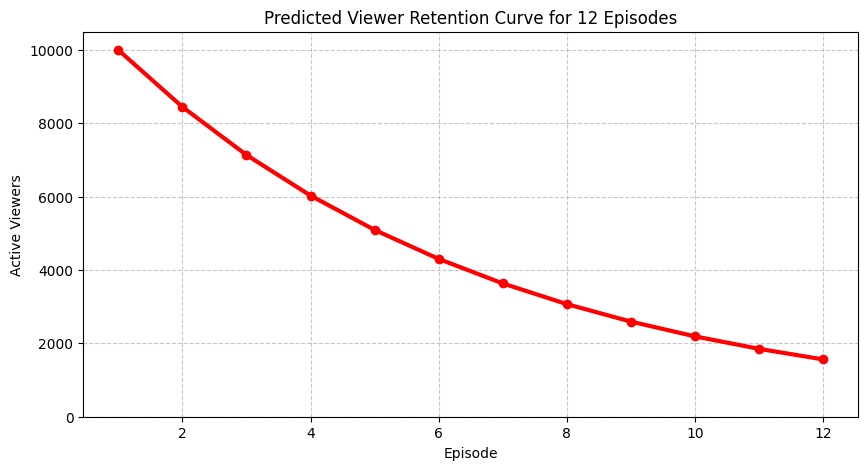

In [46]:
#Markov Chain Simulation :)

def simulate_season(anime_features,model,starting_viewers=10000):
    # predict_proba returns [Probability of Flop, Probability of Hit] and...
    # We want the Probability of Hit (of index 1)
    hit_prob=model.predict_proba(anime_features)[0][1]

    # converting that confidence into a Weekly Retention Rate
    # Base rate of 70%, plus up to 25% bonus based on how confident my model is
    weekly_ret_rate=0.7+0.25*hit_prob
    viewers=[starting_viewers]

    # running the 12-week Markov Chain simulation (range is 2 to 13 as i've already started with a week1 of 10k audience)
    for episode in range(2,13):
        retained=int(viewers[-1]*weekly_ret_rate)
        viewers.append(retained)

    return viewers,hit_prob

# Let's test it on the first row of our unseen X_test data...
test_anime=X_test.iloc[[0]]

curve,confidence=simulate_season(test_anime,model)

print(f"The confidence of model a.k.a hit probabilty is {confidence*100:.2f}")
print(f"Episode 1 viewers: {curve[0]}")
print(f"Episode 12 viewers: {curve[-1]}")

plt.figure(figsize=(10,5))
plt.plot(range(1,13),curve,marker='o',lw=3, c='red')
plt.title("Predicted Viewer Retention Curve for 12 Episodes")
plt.xlabel("Episode")
plt.ylabel("Active Viewers")
plt.ylim(0,10500)
plt.grid(True,ls='--',alpha=0.7)
plt.show()

In [47]:
import joblib

joblib.dump(model, 'anime_model.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Brain successfully exported!")

Brain successfully exported!
